In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/kickstarter_us_filtered.csv")




In [3]:
df.shape

(38504, 17)

In [4]:
df.groupby("status")[["goal"]].describe()

goal                                                     \
              count          mean            std   min     25%     50%   
status                                                                   
failed      17429.0  16565.287451  228351.812875  0.50  2500.0  5000.0   
successful  21075.0   5431.762588   12640.637535  0.01  1200.0  3000.0   

                                  
                75%          max  
status                            
failed      12000.0  21474836.47  
successful   6000.0    900000.00

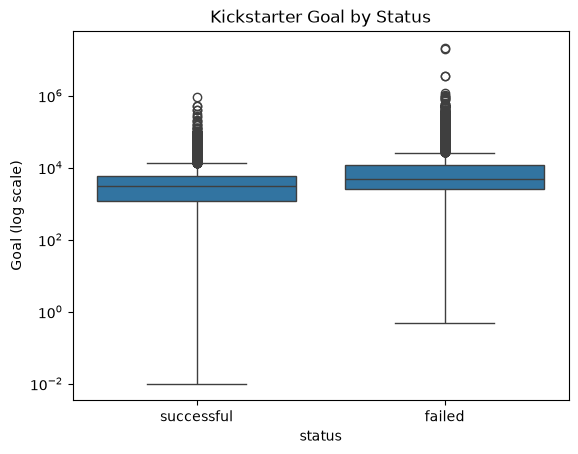

In [ ]:
sns.boxplot(x="status", y="goal", data=df)
plt.title("Kickstarter Goal by Status")
plt.yscale("log")
plt.ylabel("Goal (log scale)")
plt.show()
# Median goal for failed campaigns ($5,000) was higher than for 
# successful campaigns ($3,000), but the distributions overlap 
# substantially, and both are heavily right-skewed with extreme outliers.

goal_bucket
$0-1k          6895
$1k-5k        17651
$5k-10k        7162
$10k-50k       5989
$50k-100k       539
$100k-500k      250
$500k-1M         12
$1M+              6
Name: count, dtype: int64
status
successful    21075
failed        17429
Name: count, dtype: int64
status         failed  successful
goal_bucket                      
$0-1k        0.310080    0.689920
$1k-5k       0.393122    0.606878
$5k-10k      0.514242    0.485758
$10k-50k     0.662381    0.337619
$50k-100k    0.844156    0.155844
$100k-500k   0.920000    0.080000
$500k-1M     0.916667    0.083333
$1M+         1.000000    0.000000


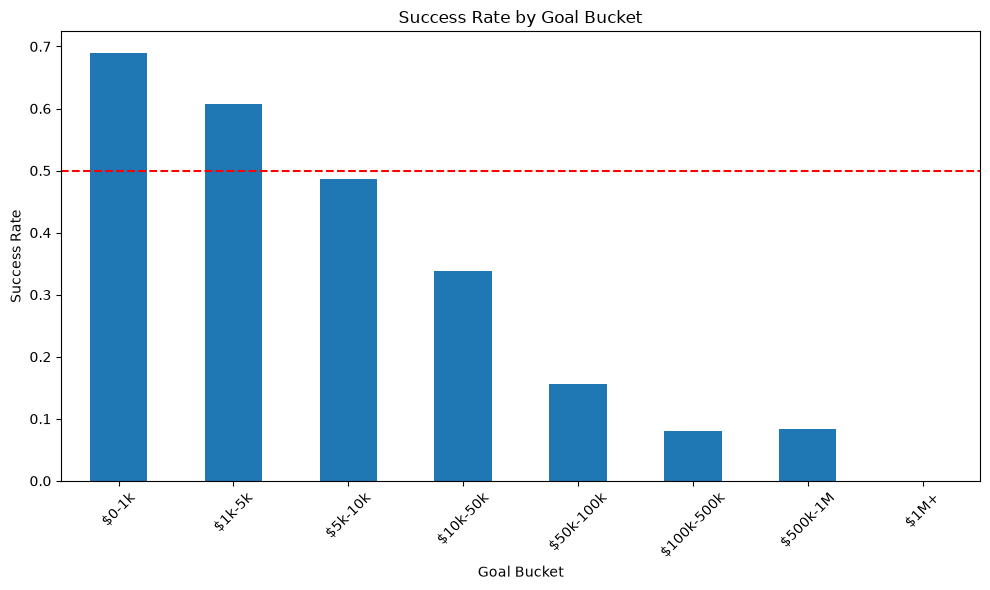

In [ ]:
df["goal_bucket"] = pd.cut(df["goal"], bins=[0, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, float('inf')], labels=["$0-1k", "$1k-5k", "$5k-10k", "$10k-50k", "$50k-100k", "$100k-500k", "$500k-1M", "$1M+"])
print(df['goal_bucket'].value_counts().sort_index())
print(df['status'].value_counts())
print(df.groupby("goal_bucket")["status"].value_counts(normalize=True).unstack().fillna(0))

success_rates = df.groupby("goal_bucket")["status"].value_counts(normalize=True).unstack().fillna(0)["successful"]
success_rates.plot(kind="bar", figsize=(10, 6))
plt.title("Success Rate by Goal Bucket")
plt.ylabel("Success Rate")
plt.xlabel("Goal Bucket")
plt.xticks(rotation=45)
plt.tight_layout()
plt.axhline(0.5, color="red", linestyle="--")
plt.show()

## Findings: Goal Amount vs. Success

**Median comparison.** Failed campaigns had a higher median goal (USD 5,000) than successful campaigns (USD 3,000). The gap holds across the distribution: the 25th percentile was USD 2,500 vs. USD 1,200 and the 75th was USD 12,000 vs. USD 6,000.

**Overlap.** The two groups overlap substantially in the boxplot, so goal size alone does not cleanly separate successful from failed campaigns. It is related to the outcome, but it is one factor among several.

**Threshold effect.** Success rate declines steadily as goals grow: about 69% for USD 0-1k, 61% for USD 1k-5k, 49% for USD 5k-10k, 34% for USD 10k-50k, 16% for USD 50k-100k, and 8% for USD 100k-500k. A campaign becomes more likely to fail than succeed at roughly the USD 5k-10k range. This is a gradual decline rather than a single cliff, with the steepest drops between USD 5k-10k and USD 50k-100k.

**Caveats.** Goal is heavily right-skewed (failed mean USD 16,565 vs. median USD 5,000), so medians are more reliable than means. The data contains suspect values, such as a maximum goal of USD 21,474,836.47 (close to a 32-bit integer limit divided by 100) and minimums of USD 0.01 and USD 0.50. The top buckets are too small to interpret (USD 500k-1M has 12 campaigns and USD 1M+ has 6, with a 0% success rate in the latter). These results show association, not causation.